In [1]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/microsoft/microsoft_data.csv')

In [4]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,3.155715,13648.0,2977.0,68853.0,31910.0,36943.0,-3.23,0.15
1,1,2009-06-30,4.275766,13099.0,3045.0,77888.0,38330.0,39558.0,-3.98,0.16
2,2,2009-09-30,5.564228,12920.0,3574.0,81612.0,40400.0,41212.0,-3.13,0.12
3,3,2009-12-31,6.326140,19022.0,6662.0,82096.0,37813.0,44283.0,0.11,0.11
4,4,2010-03-31,7.054728,14503.0,4006.0,84910.0,39200.0,45710.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,209.401932,64727.0,22036.0,512163.0,243686.0,268477.0,3.04,5.33
62,62,2024-09-30,231.920639,65585.0,24667.0,523013.0,235290.0,287723.0,2.72,4.83
63,63,2024-12-31,249.534180,69632.0,24108.0,533898.0,231203.0,302695.0,2.53,4.33
64,64,2025-03-31,221.587616,70066.0,25824.0,562624.0,240733.0,321891.0,1.99,4.33


In [7]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [9]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]


data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,45.390198,30571.0,8809.0,1.563269,94864.0,1.93,2.42
41,2019-06-30,47.476845,33717.0,13187.0,1.555459,102330.0,2.24,2.40
42,2019-09-30,53.929817,33055.0,10678.0,1.613445,106061.0,2.80,1.83
43,2019-12-31,70.920357,36906.0,11649.0,1.637629,110109.0,3.35,1.55
44,2020-03-31,61.560165,35021.0,10752.0,1.669800,114501.0,1.28,0.05
45,2020-06-30,88.552185,38033.0,11202.0,1.646445,118304.0,-7.50,0.09
46,2020-09-30,112.650452,37154.0,13893.0,1.694740,123392.0,-1.41,0.09
47,2020-12-31,129.292587,43076.0,15463.0,1.748909,130236.0,-1.02,0.09
48,2021-03-31,119.200325,41706.0,15457.0,1.771359,134505.0,1.76,0.07
49,2021-06-30,133.879745,46152.0,16458.0,1.740327,141988.0,12.24,0.10


In [10]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 8    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15358/3423240762.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [11]:
growth_rates

{'revenue_musd': np.float64(0.035027333783326293),
 'net_income_musd': np.float64(-0.24488107195022082),
 'share_holder_equity_musd': np.float64(0.03608069196147448),
 'gdp_growth': np.float64(2.0990909090909096),
 'interest_rate': np.float64(1.2978787878787879)}

In [12]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



18:18:26 - cmdstanpy - INFO - Chain [1] start processing
18:18:26 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
62 2024-09-30  222.387988  206.601970  237.890643  231.920639
63 2024-12-31  224.282392  208.745619  240.100965  249.534180
64 2025-03-31  225.487250  209.920064  240.014207  221.587616
65 2025-06-30  244.767429  229.513296  259.703364  204.937408
66 2025-09-30  276.575638  261.529651  291.805333         NaN
67 2025-12-31  267.114528  251.596406  282.319777         NaN
68 2026-03-31  297.468409  281.560769  311.413131         NaN
69 2026-06-30  299.393402  283.757705  313.782510         NaN
70 2026-09-30  324.164913  308.849862  339.192352         NaN
71 2026-12-31  318.080247  303.456129  333.411675         NaN
72 2027-03-31  354.782517  339.741822  369.696978         NaN
73 2027-06-30  363.867997  348.226385  379.307808         NaN


In [13]:
#7) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 9.31034831618018
RMSE: 140.5417958413709
R²: 0.971982161339096
           ds        yhat  yhat_lower  yhat_upper           y  is_future
62 2024-09-30  222.387988  206.601970  237.890643  231.920639      False
63 2024-12-31  224.282392  208.745619  240.100965  249.534180      False
64 2025-03-31  225.487250  209.920064  240.014207  221.587616      False
65 2025-06-30  244.767429  229.513296  259.703364  204.937408      False
66 2025-09-30  276.575638  261.529651  291.805333         NaN       True
67 2025-12-31  267.114528  251.596406  282.319777         NaN       True
68 2026-03-31  297.468409  281.560769  311.413131         NaN       True
69 2026-06-30  299.393402  283.757705  313.782510         NaN       True
70 2026-09-30  324.164913  308.849862  339.192352         NaN       True
71 2026-12-31  318.080247  303.456129  333.411675         NaN       True
72 2027-03-31  354.782517  339.741822  369.696978         NaN       True
73 2027-06-30  363.867997  348.226385  379.307808       

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15358/327559522.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


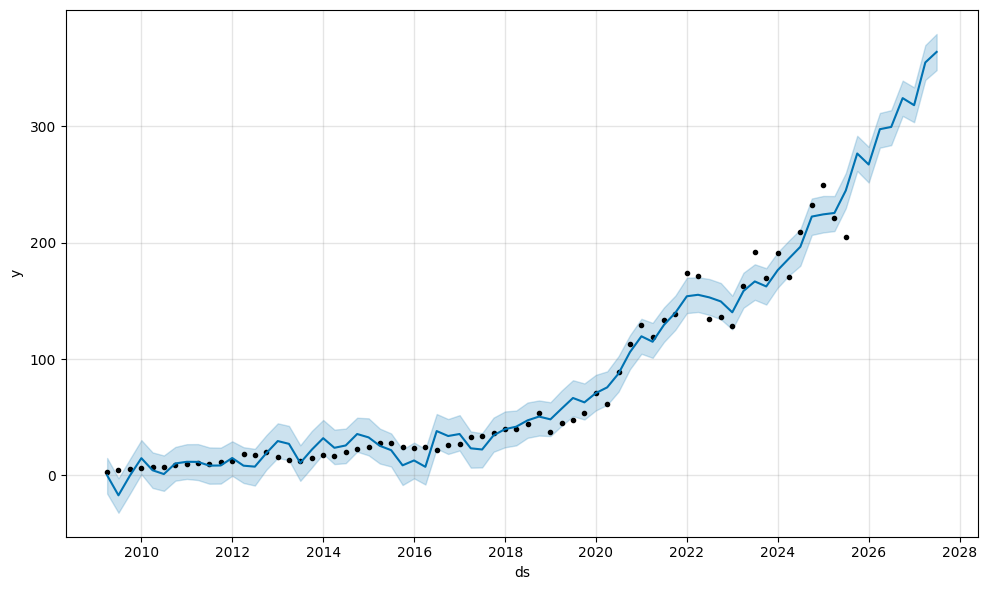

In [14]:
figl = m.plot(forecast)
figl.show()

In [26]:
correlations = data.corr()
correlations

,ds,y,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
ds,1.000000,0.906402,0.903409,0.835994,-0.265540,0.858967,0.124506,0.732953
y,0.906402,1.000000,0.970293,0.938241,0.056362,0.956064,0.144328,0.777427
revenue,0.903409,0.970293,1.000000,0.915488,0.050396,0.952574,0.131277,0.773328
net_income,0.835994,0.938241,0.915488,1.000000,0.141435,0.906925,0.125296,0.733397
ratio assets/libailities,-0.265540,0.056362,0.050396,0.141435,1.000000,0.204939,-0.002103,0.061692
shareholders_equity,0.858967,0.956064,0.952574,0.906925,0.204939,1.000000,0.114128,0.825710
gdp_growth,0.124506,0.144328,0.131277,0.125296,-0.002103,0.114128,1.000000,0.081124
interest_rate,0.732953,0.777427,0.773328,0.733397,0.061692,0.825710,0.081124,1.000000
